<a href="https://colab.research.google.com/github/nikunshvaish-droid/be_practical_trainning_day_7/blob/main/Day7_Notebook_01_Ensembles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET GENERATION (telecom_churn_ensembles.csv)
# Run this cell first. Installs dependencies and creates the tabular dataset.
# ==============================================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Core Suite
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

np.random.seed(42)
N = 3000

# Synthetic Tabular Telecom Customer Retention Dataset
account_length = np.random.exponential(scale=24, size=N).clip(1, 72).astype(int)
monthly_charges = np.random.normal(loc=70, scale=28, size=N).clip(18, 140)
total_data_gb = np.random.gamma(shape=3.0, scale=8.0, size=N).clip(0.5, 100)
customer_service_calls = np.random.poisson(lam=1.6, size=N)
international_plan = np.random.binomial(n=1, p=0.12, size=N)
roaming_minutes = np.random.exponential(scale=10, size=N).clip(0, 60) * international_plan
tech_support_active = np.random.binomial(n=1, p=0.40, size=N)

# Complex non-linear interaction terms defining ground truth churn
interaction_score = (
    - 2.8
    + 0.025 * monthly_charges
    - 0.045 * account_length
    + 0.65 * customer_service_calls
    + 1.8 * (customer_service_calls >= 4)  # Sharp non-linear step threshold
    + 1.4 * international_plan
    - 1.1 * tech_support_active
    + 0.03 * (monthly_charges * (1 - tech_support_active))  # Interaction term
    - 0.02 * total_data_gb
)
churn_probability = 1 / (1 + np.exp(-interaction_score))
churn_label = np.where(np.random.rand(N) < churn_probability, 1, 0)

churn_df = pd.DataFrame({
    "Account_Length_Months": account_length,
    "Monthly_Charges_USD": np.round(monthly_charges, 2),
    "Total_Data_GB": np.round(total_data_gb, 2),
    "Customer_Service_Calls": customer_service_calls,
    "International_Plan": international_plan,
    "Roaming_Minutes": np.round(roaming_minutes, 2),
    "Tech_Support_Active": tech_support_active,
    "Churn": churn_label
})

churn_df.to_csv("telecom_churn_ensembles.csv", index=False)
print("✅ Dataset 'telecom_churn_ensembles.csv' generated successfully!")
print(f"Dimensions: {churn_df.shape[0]:,} rows × {churn_df.shape[1]} features")
print(f"Target Distribution (Churn Rate): {churn_df['Churn'].mean()*100:.2f}%")
display(churn_df.head(3))

✅ Dataset 'telecom_churn_ensembles.csv' generated successfully!
Dimensions: 3,000 rows × 8 features
Target Distribution (Churn Rate): 44.43%


,Account_Length_Months,Monthly_Charges_USD,Total_Data_GB,Customer_Service_Calls,International_Plan,Roaming_Minutes,Tech_Support_Active,Churn
0,11,99.68,30.40,1,0,0.0,0,1
1,72,87.28,26.62,4,0,0.0,0,1
2,31,89.14,23.60,0,0,0.0,0,1


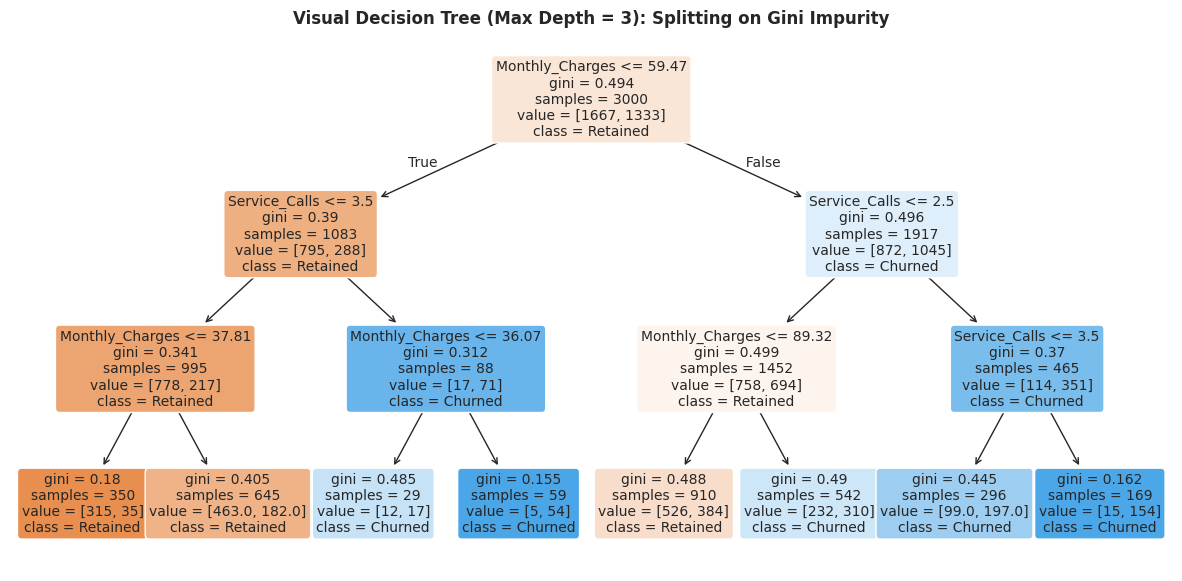

In [ ]:
# ==============================================================================
# SECTION 1: DECISION TREE MECHANICS & SPLITTING CRITERIA
# ==============================================================================
"""
DECISION TREE MATHEMATICS:

1. SPLITTING CRITERIA (IMPURITY MEASURES):
   For a binary classification node with class proportions p₁ and p₂:

   A. Gini Impurity:
      Gini(D) = 1 - Σ (p_k)² = 1 - (p₁² + p₂²)
      - Range: [0.0 (Pure Node) to 0.5 (Maximum Disorder / 50-50 Split)]
      - Computationally faster (no logarithm). Default in Scikit-Learn.

   B. Shannon Entropy:
      Entropy(D) = - Σ [ p_k * log₂(p_k) ]
      - Range: [0.0 (Pure Node) to 1.0 (Maximum Disorder)]

   C. Information Gain (IG):
      IG(D, Feature) = Entropy(Parent) - Σ [ (|D_v| / |D|) * Entropy(Child_v) ]
      - The algorithm tests every continuous threshold across all features and picks
        the (feature, threshold) pair that MAXIMIZES Information Gain / Gini Reduction.

2. OVERFITTING & PRUNING HYPERPARAMETERS:
   - max_depth: Limits tree vertical growth (prevents memorizing leaf noise).
   - min_samples_split: Minimum instances required in a node to attempt a split.
   - min_samples_leaf: Minimum instances required in a terminal leaf node.
   - ccp_alpha: Cost-Complexity Pruning parameter (minimal cost-complexity pruning).
"""

# Visualizing Decision Tree Splitting on 2 Core Features
X_demo = churn_df[["Customer_Service_Calls", "Monthly_Charges_USD"]]
y_demo = churn_df["Churn"]

dt_shallow = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
dt_shallow.fit(X_demo, y_demo)

plt.figure(figsize=(15, 7))
plot_tree(
    dt_shallow,
    feature_names=["Service_Calls", "Monthly_Charges"],
    class_names=["Retained", "Churned"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Visual Decision Tree (Max Depth = 3): Splitting on Gini Impurity", fontweight="bold")
plt.show()

In [ ]:
# ==============================================================================
# SECTION 2: ENSEMBLE PARADIGMS — BAGGING VS BOOSTING
# ==============================================================================
"""
WHY ENSEMBLES WORK: CONDORCET'S JURY THEOREM
If you aggregate N independent classifiers, each with an accuracy p > 0.50,
the probability of the ensemble majority vote being correct approaches 1.0 as N -> ∞.

┌────────────────────────────┬─────────────────────────────────────────────────────────┐
│ BAGGING (Bootstrap Agg.)   │ BOOSTING (Sequential Error Correction)                  │
├────────────────────────────┼─────────────────────────────────────────────────────────┤
│ • Parallel training        │ • Sequential training (Step t depends on Step t-1).     │
│ • Independent deep trees   │ • Shallow weak learners (Stumps / Depth 3-6).           │
│ • Reduces VARIANCE (Spread)│ • Reduces BIAS (Error) & Variance.                      │
│ • Example: Random Forest   │ • Examples: AdaBoost, Gradient Boosting, XGBoost.       │
└────────────────────────────┴─────────────────────────────────────────────────────────┘
"""

In [ ]:
# ==============================================================================
# SECTION 3: RANDOM FORESTS (BAGGING + FEATURE SUBSPACING)
# ==============================================================================
"""
RANDOM FOREST CORE INNOVATIONS:
1. Bootstrap Sampling: Each tree is trained on an independent resample with replacement (63.2% unique rows).
2. Random Subspace (Feature Bagging): At every node split, only a random subset of
   features (typically √p for classification) is considered. This DE-CORRELATES the trees!
3. Out-Of-Bag (OOB) Score: Evaluates each tree on the ~36.8% unselected rows;
   provides a built-in cross-validation estimate without a separate validation split.
4. Mean Decrease in Impurity (MDI): Measures total Gini reduction attributable to each feature.
"""

X_all = churn_df.drop(columns=["Churn"])
y_all = churn_df["Churn"]

# Train Random Forest with OOB Evaluation
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    max_features="sqrt",
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_all, y_all)

print("=== RANDOM FOREST OOB EVALUATION ===")
print(f"Out-of-Bag (OOB) Generalization Accuracy: {rf_model.oob_score_*100:.2f}%")

=== RANDOM FOREST OOB EVALUATION ===
Out-of-Bag (OOB) Generalization Accuracy: 81.73%


In [ ]:
# ==============================================================================
# SECTION 4: BOOSTING EVOLUTION: ADABOOST -> GRADIENT BOOSTING -> XGBOOST
# ==============================================================================
"""
THE EVOLUTION OF BOOSTING ALGORITHMS:

1. ADABOOST (Adaptive Boosting):
   - Reweights training instances: Increases sample weights of misclassified rows so the
     next decision stump focuses on hard examples.

2. GRADIENT BOOSTING MACHINE (GBM):
   - Gradient Descent in Function Space: Fits sequential trees to the PSEUDO-RESIDUALS
     (negative gradients of the loss function) of the previous cumulative ensemble:
     F_m(x) = F_{m-1}(x) + η * h_m(x)   (where η is learning rate).

3. XGBOOST (Extreme Gradient Boosting) — WHY IT DOMINATES TABULAR COMPETITIONS:
   - 2nd-Order Taylor Approximation: Uses both Gradients (g_i) AND Hessians (h_i) for exact optimization.
   - Built-in Regularization: L1 (α) and L2 (λ) penalty on leaf weights prevents tree overfitting.
   - Pruning via Gain Threshold: Prunes negative gain branches using γ (gamma).
   - Sparsity-Aware Split Finding: Automatically handles missing values in hardware routines.
   - Cache-Aware Block Processing: Multi-threaded parallelization over CPU registers.

KEY BOOSTING HYPERPARAMETERS:
- n_estimators: Number of sequential boosting rounds.
- learning_rate (η): Shrinkage factor applied to each new tree (typically 0.01 - 0.10).
- max_depth: Depth of individual weak learners (typically 3 - 6).
- subsample: Row subsampling fraction per tree (e.g., 0.80).
- colsample_bytree: Feature subsampling fraction per tree (e.g., 0.80).
"""

'\nTHE EVOLUTION OF BOOSTING ALGORITHMS:\n\n1. ADABOOST (Adaptive Boosting):\n   - Reweights training instances: Increases sample weights of misclassified rows so the \n     next decision stump focuses on hard examples.\n\n2. GRADIENT BOOSTING MACHINE (GBM):\n   - Gradient Descent in Function Space: Fits sequential trees to the PSEUDO-RESIDUALS \n     (negative gradients of the loss function) of the previous cumulative ensemble:\n     F_m(x) = F_{m-1}(x) + η * h_m(x)   (where η is learning rate).\n\n3. XGBOOST (Extreme Gradient Boosting) — WHY IT DOMINATES TABULAR COMPETITIONS:\n   - 2nd-Order Taylor Approximation: Uses both Gradients (g_i) AND Hessians (h_i) for exact optimization.\n   - Built-in Regularization: L1 (α) and L2 (λ) penalty on leaf weights prevents tree overfitting.\n   - Pruning via Gain Threshold: Prunes negative gain branches using γ (gamma).\n   - Sparsity-Aware Split Finding: Automatically handles missing values in hardware routines.\n   - Cache-Aware Block Processi

In [ ]:
# ==============================================================================
# SECTION 5: NON-TREE CLASSIFIERS: KNN, SVM & NAIVE BAYES
# ==============================================================================
"""
1. K-NEAREST NEIGHBOURS (KNN):
   - Instance-based non-parametric lazy learner.
   - Distance Metrics: Euclidean (L2), Manhattan (L1), Minkowski (L_p).
   - Hyperparameter K: Small k -> Overfitting/Noise sensitive; Large k -> High bias/Oversmoothing.
   - MANDATORY RULE: MUST SCALE FEATURES! Large-scale features dominate Euclidean distance.
   - Curse of Dimensionality: Distance metrics break down in high-dimensional sparse spaces.

2. SUPPORT VECTOR MACHINES (SVM):
   - Finds the Optimal Maximum Margin Hyperplane that maximizes geometric distance to nearest Support Vectors.
   - Hinge Loss & C parameter: High C = Narrow margin (low bias, high variance); Low C = Wide margin (slack).
   - THE KERNEL TRICK: Computes inner products in implicit infinite-dimensional space without transforming data:
     * Linear Kernel: K(x, z) = xᵀz
     * RBF (Radial Basis Function / Gaussian) Kernel: K(x, z) = exp(-γ ||x - z||²)
     * γ (gamma): High γ = Localized bell curves (overfit); Low γ = Generalized smooth curves.

3. NAIVE BAYES:
   - Applies Bayes' Theorem with the strong "Naive" assumption that all features are
     CONDITIONALLY INDEPENDENT given the target class label:
     P(y | x₁, ..., x_p) ∝ P(y) * Π P(x_i | y)
   - Extremely fast, zero hyperparameter tuning, performs exceptionally well on text/NLP (Bag of Words / TF-IDF).
"""

In [ ]:
# ==============================================================================
# SECTION 6: ALGORITHM SELECTION DECISION FRAMEWORK
# ==============================================================================
"""
THE INDUSTRY ALGORITHM SELECTION MATRIX:

┌─────────────────────┬───────────────────┬───────────────┬────────────────┬───────────────────────────┐
│ Algorithm           │ Interpretability  │ Training Speed│ Non-Linearity? │ When to Choose in Industry│
├─────────────────────┼───────────────────┼───────────────┼────────────────┼───────────────────────────┤
│ Logistic Regression │ High (Odds Ratio) │ Instantaneous │ Linear Only    │ Baseline, Regulated (Risk)│
│ K-Nearest Neighbors │ Moderate (Local)  │ Fast (Lazy)   │ Yes (Local)    │ Small N, Recommendation   │
│ Decision Tree       │ High (Flowchart)  │ Fast          │ Yes (Step-wise)│ Human-in-the-loop rules   │
│ Random Forest       │ Moderate (MDI)    │ Moderate (CPU)│ High           │ Tabular robust baseline   │
│ XGBoost / LightGBM  │ Moderate (Gain)   │ Fast (GPU/Opt)│ State-of-the-Art Production Tabular ML│
│ Support Vector Mach.│ Low (Black Box)   │ Slow (O(N³))  │ High (Kernels) │ High-dimensional, small N │
│ Naive Bayes         │ Moderate          │ Instantaneous │ Weak           │ Spam, NLP Text Baselines  │
└─────────────────────┴───────────────────┴───────────────┴────────────────┴───────────────────────────┘
"""

=== TREE ENSEMBLE PERFORMANCE COMPARISON ===


,Accuracy,ROC-AUC Score,F1-Score,Training Time (ms)
Model,,,,
Decision Tree (Tuned),0.8000,0.8633,0.7834,9.51
Random Forest,0.8167,0.8935,0.7909,941.70
XGBoost Classifier,0.8300,0.8930,0.8083,1114.44


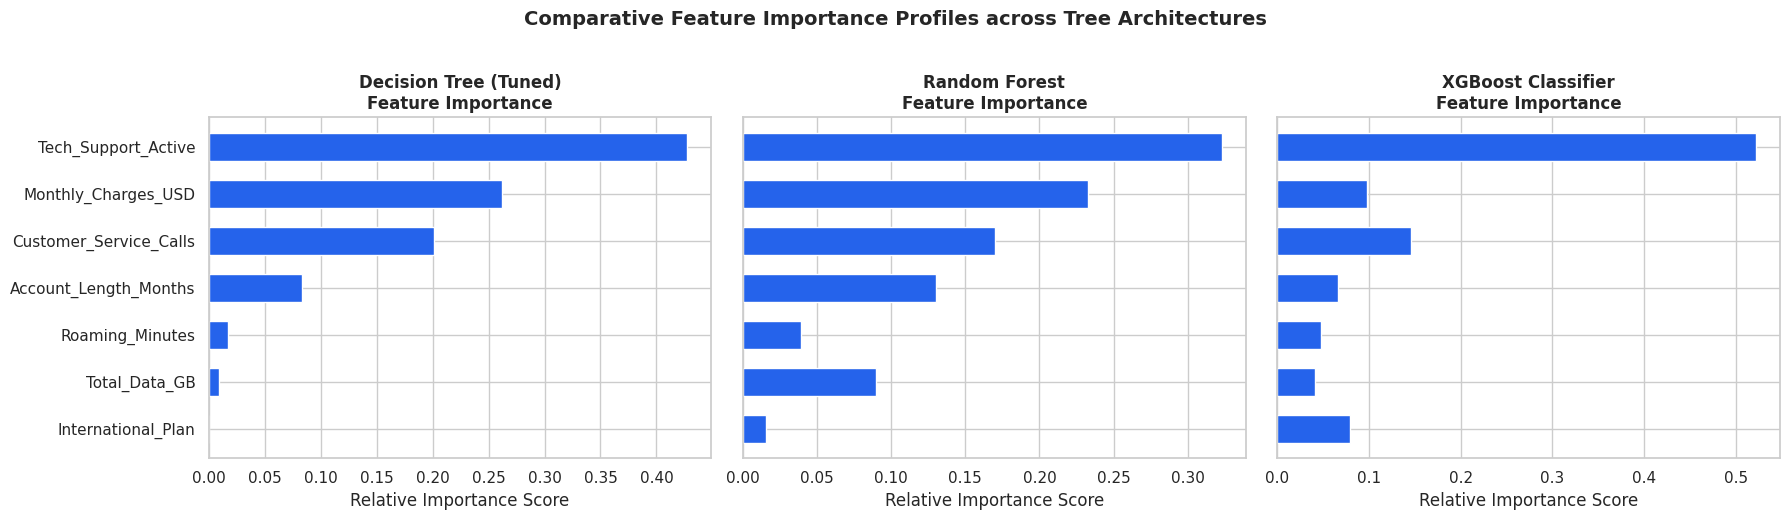

In [ ]:
# ==============================================================================
# SECTION 7: LIVE DEMO — THE TREE TRIO SHOWDOWN (DT VS RF VS XGBOOST)
# ==============================================================================
# Split Dataset into Train/Test Sets
X = churn_df.drop(columns=["Churn"])
y = churn_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Benchmark Suite Definition
models_trio = {
    "Decision Tree (Tuned)": DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "XGBoost Classifier": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="logloss")
}

benchmark_results = []
feature_importances = {}

for name, clf in models_trio.items():
    start_time = time.time()
    clf.fit(X_train, y_train)
    elapsed_ms = (time.time() - start_time) * 1000

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    benchmark_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC Score": roc_auc_score(y_test, y_prob),
        "F1-Score": f1_score(y_test, y_pred),
        "Training Time (ms)": np.round(elapsed_ms, 2)
    })

    feature_importances[name] = clf.feature_importances_

print("=== TREE ENSEMBLE PERFORMANCE COMPARISON ===")
display(pd.DataFrame(benchmark_results).set_index("Model").round(4))

# Side-by-Side Feature Importance Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (model_name, importances) in zip(axes, feature_importances.items()):
    sorted_idx = np.argsort(importances)
    ax.barh(X.columns[sorted_idx], importances[sorted_idx], color="#2563eb", height=0.6)
    ax.set_title(f"{model_name}\nFeature Importance", fontweight="bold")
    ax.set_xlabel("Relative Importance Score")

plt.suptitle("Comparative Feature Importance Profiles across Tree Architectures", fontsize=14, y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

In [3]:
# ==============================================================================
# SECTION 8: STUDENT GRADED LAB — THE 5-ALGORITHM SHOWDOWN
# ==============================================================================
"""
🎓 STUDENT LAB INSTRUCTIONS:
Evaluate 5 distinct algorithmic families on `churn_df` using Stratified 5-Fold Cross-Validation:
  1. Logistic Regression (Requires Standard Scaling)
  2. K-Nearest Neighbors (Requires Standard Scaling, k=9)
  3. Support Vector Machine (Requires Standard Scaling, RBF Kernel)
  4. Random Forest Classifier (Tree-based, 150 Estimators)
  5. XGBoost Classifier (Gradient Boosted Trees, 150 Estimators, lr=0.08)

MANDATORY TASKS:
1. Build individual Scikit-Learn Pipelines (encapsulating StandardScaler where mathematically mandatory).
2. Evaluate each model across 5 Stratified Folds for:
   - ROC-AUC
   - Accuracy
   - F1-Score
3. Aggregate the Mean ± Std into a clean benchmark comparison DataFrame.
4. Identify which algorithm achieves top-rank generalization performance on tabular data.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE
# ------------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Fallback: Regenerate the dataset locally if not found
if 'churn_df' not in locals() and 'churn_df' not in globals():
    if os.path.exists("telecom_churn_ensembles.csv"):
        churn_df = pd.read_csv("telecom_churn_ensembles.csv")
    else:
        # Local inline dataset generation to guarantee success
        np.random.seed(42)
        N = 3000
        account_length = np.random.exponential(scale=24, size=N).clip(1, 72).astype(int)
        monthly_charges = np.random.normal(loc=70, scale=28, size=N).clip(18, 140)
        total_data_gb = np.random.gamma(shape=3.0, scale=8.0, size=N).clip(0.5, 100)
        customer_service_calls = np.random.poisson(lam=1.6, size=N)
        international_plan = np.random.binomial(n=1, p=0.12, size=N)
        roaming_minutes = np.random.exponential(scale=10, size=N).clip(0, 60) * international_plan
        tech_support_active = np.random.binomial(n=1, p=0.40, size=N)
        interaction_score = (
            - 2.8
            + 0.025 * monthly_charges
            - 0.045 * account_length
            + 0.65 * customer_service_calls
            + 1.8 * (customer_service_calls >= 4)
            + 1.4 * international_plan
            - 1.1 * tech_support_active
            + 0.03 * (monthly_charges * (1 - tech_support_active))
            - 0.02 * total_data_gb
        )
        churn_probability = 1 / (1 + np.exp(-interaction_score))
        churn_label = np.where(np.random.rand(N) < churn_probability, 1, 0)
        churn_df = pd.DataFrame({
            "Account_Length_Months": account_length,
            "Monthly_Charges_USD": np.round(monthly_charges, 2),
            "Total_Data_GB": np.round(total_data_gb, 2),
            "Customer_Service_Calls": customer_service_calls,
            "International_Plan": international_plan,
            "Roaming_Minutes": np.round(roaming_minutes, 2),
            "Tech_Support_Active": tech_support_active,
            "Churn": churn_label
        })
        churn_df.to_csv("telecom_churn_ensembles.csv", index=False)

# Define target and features
X_lab = churn_df.drop(columns=["Churn"])
y_lab = churn_df["Churn"]

# Define candidate pipelines
pipelines = {
    "1. Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "2. K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=9))
    ]),
    "3. Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "4. Random Forest Classifier": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1))
    ]),
    "5. XGBoost Classifier": Pipeline([
        ("clf", XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.08, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="logloss"))
    ])
}

# Setup Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "roc_auc", "f1"]

results_list = []

# Run Cross Validation
for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_lab, y_lab, cv=cv, scoring=scoring, n_jobs=-1)

    results_list.append({
        "Model": name,
        "Accuracy (Mean)": scores["test_accuracy"].mean(),
        "Accuracy (Std)": scores["test_accuracy"].std(),
        "ROC-AUC (Mean)": scores["test_roc_auc"].mean(),
        "ROC-AUC (Std)": scores["test_roc_auc"].std(),
        "F1-Score (Mean)": scores["test_f1"].mean(),
        "F1-Score (Std)": scores["test_f1"].std()
    })

# Final Benchmark Comparison Table
benchmark_df = pd.DataFrame(results_list)

# Create a beautifully formatted presentation dataframe
formatted_df = pd.DataFrame()
formatted_df["Model"] = benchmark_df["Model"]
formatted_df["Accuracy"] = benchmark_df.apply(lambda r: f"{r['Accuracy (Mean)']:.4f} ± {r['Accuracy (Std)']:.4f}", axis=1)
formatted_df["ROC-AUC"] = benchmark_df.apply(lambda r: f"{r['ROC-AUC (Mean)']:.4f} ± {r['ROC-AUC (Std)']:.4f}", axis=1)
formatted_df["F1-Score"] = benchmark_df.apply(lambda r: f"{r['F1-Score (Mean)']:.4f} ± {r['F1-Score (Std)']:.4f}", axis=1)

print("=== 5-ALGORITHM BENCHMARK RESULTS (5-FOLD CV) ===")
display(formatted_df.set_index("Model"))

=== 5-ALGORITHM BENCHMARK RESULTS (5-FOLD CV) ===


,Accuracy,ROC-AUC,F1-Score
Model,,,
1. Logistic Regression,0.8170 ± 0.0123,0.8940 ± 0.0099,0.7906 ± 0.0150
2. K-Nearest Neighbors,0.8113 ± 0.0076,0.8729 ± 0.0092,0.7825 ± 0.0109
3. Support Vector Machine,0.8173 ± 0.0070,0.8899 ± 0.0037,0.7911 ± 0.0084
4. Random Forest Classifier,0.8193 ± 0.0116,0.8896 ± 0.0085,0.7934 ± 0.0161
5. XGBoost Classifier,0.8113 ± 0.0129,0.8892 ± 0.0076,0.7835 ± 0.0178
